# How to use this notebook — Quick run guide ✅

1. Phase 0: Enter your session directory and choose a protocol (Online/Offline). Click **Load Session**.  
2. Phase 1: Select a discovered recording and click **Open Recording**. Check the sample rate and channel names printed.  
3. Phase 1: Run the EMG processing cell — it will apply the chosen protocol (offline → bandpass via `lfilter`, online → uses prefiltered channel).  
4. Phase 1: Use segment navigation to inspect long recordings.  
5. Phase 1: Run the MessageCenter loader to load `text.npy` and `timestamps.npy` used for trigger/stim messages.  
6. Phase 2: Run the blanking and binning cell — this creates `blank_mask` and runs an example trial sweep.  
7. Phase 3: Run peri-stim extraction and grouping by stimulation amplitude to compute averaged peri-stim EMG traces and detect M/H peaks.  
8. Phase 4: Run recruitment normalization and save the results as a JSON summary.  

Notes & tips:
- Adjust `blank_pre_ms` / `blank_post_ms` to tune how conservatively you exclude MEP-contaminated samples.  
- `min_valid_fraction` controls the required fraction of valid samples per bin; increase to be more strict.  
- For long recordings, avoid preloading everything into memory if you have low RAM — you can adapt the `sweep_trials` routine to operate on chunks.  

If you'd like, I can now:
- Add a ``Save trials`` cell (NPZ/CSV) and a small demo loader to reload and inspect saved trials, or
- Integrate this offline pipeline into the `emg_characterization_stage` class (for reuse in the GUI streaming pipeline), or
- Add automated tests for the helper functions.

Which would you like me to implement next?

# EMG Characterization Offline Analysis — Phase 0: Setup & Configuration

This notebook is a full rewrite of the EMG characterization offline analysis. Phase 0 loads
required libraries, defines constants and configuration, and provides a UI to select a session
folder and the processing protocol (Online Filtering or Offline Filtering). We will adopt the
file/data handling patterns from `Respiration_offline.ipynb` and `Plot_1_Online_Diff.ipynb` /
`Plot_2_Offline_FWD_Filt.ipynb` as we proceed.


In [22]:
# Phase 0: Imports and Constants (from helpers.py)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from open_ephys.analysis import Session
import json
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from helpers import *

# Override default protocol for this notebook
DEFAULT_PROTOCOL = PROTOCOL_OFFLINE

print("Phase 0: imports and constants loaded. Default protocol:", DEFAULT_PROTOCOL)

Phase 0: imports and constants loaded. Default protocol: Offline Filtering


In [23]:
# Phase 0: Session selection UI
dir_text = widgets.Text(value=os.getcwd(), description='Session dir:', layout=widgets.Layout(width='70%'))
protocol_dropdown = widgets.Dropdown(options=PROTOCOL_OPTIONS, value=DEFAULT_PROTOCOL, description='Protocol:')
recordnode_dropdown = widgets.Dropdown(options=[], description='Record Node:',
                                       layout=widgets.Layout(width='300px', overflow='visible'))
load_button = widgets.Button(description='Load Session', button_style='primary')
output = widgets.Output(layout={'border': '1px solid gray'})

def on_load_clicked(b):
    with output:
        clear_output()
        directory = dir_text.value.strip()
        if not directory:
            print("Please enter a session directory.")
            return
        try:
            s = Session(directory)
            globals()['session'] = s
            print("Session loaded from:", directory)
            try:
                nodes = [rn.name for rn in s.recordnodes]
            except Exception:
                nodes = []
            if nodes:
                recordnode_dropdown.options = nodes
                recordnode_dropdown.value = nodes[0]
            else:
                recordnode_dropdown.options = ["Record Node 106", "Record Node 111"]

            structure = scan_experiment_structure(directory, recordnode_dropdown.value)
            globals()['structure'] = structure
            print("Found experiments:", list(structure.keys()))

            flat = [(exp, r) for exp, recs in structure.items() for r in recs]
            globals()['flat_recordings'] = flat
            print(f"Discovered {len(flat)} recordings:", [f"{e}/{r}" for e, r in flat[:20]])
        except Exception as e:
            print("Warning:", e)
            structure = scan_experiment_structure(directory, recordnode_dropdown.value)
            globals()['structure'] = structure
            print("Found experiments (filesystem):", list(structure.keys()))

load_button.on_click(on_load_clicked)
display(widgets.HBox([dir_text, protocol_dropdown, load_button]))
display(recordnode_dropdown)
display(output)

Dropdown(description='Record Node:', layout=Layout(overflow='visible', width='300px'), options=(), value=None)

Output(layout=Layout(border_bottom='1px solid gray', border_left='1px solid gray', border_right='1px solid gra…

# 2. Loading the Session Data

Now let’s point Python to a specific Open Ephys session directory and create a Session object.

In [24]:
# ==== Load Session ====
#directory = '1-21-2026/HRPilot-06_Test1_2026-01-21_10-53-20_001'
#directory = '1-21-2026/HRPilot-06_Test2_2026-01-21_19-59-58_003'
#directory = '1-21-2026/HRPilot-08_Test1_2026-01-21_11-48-40_002'
#directory = '1-21-2026/HRPilot-08_Test2_2026-01-21_20-22-57_004'
#directory = '1-21-2026/HRPilot-09_Test12026-01-21_18-17-01_001'
#directory = '1-21-2026/HRPilot-10_Test1_2026-01-21_17-30-13_001'

#directory = '1-21-2026/HRPilot-10_Test2_2026-01-21_18-38-25_002'

#directory = 'HRPilot-05_FirstChronicTest1_2025-08-27_17-17-00_001'
directory = 'MDL-155_Electrode_Placement1_2025-11-18_13-43-38_001'

session = Session(directory)
print('✅ Pass Initial Test, Moving on to Loading Session...\n')

✅ Pass Initial Test, Moving on to Loading Session...



### Scanning the Session's Structure

In [25]:
record_node_name = "Record Node 106" if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else "Record Node 111"
record_node_index = 0 if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else 1
structure = scan_experiment_structure(directory, record_node_name)

# Flatten all experiment-recording pairs
flat_recordings = []
for exp_name, rec_list in structure.items():
    for rec in rec_list:
        flat_recordings.append((exp_name, rec))

print(f"Found {len(flat_recordings)} recordings across {len(structure)} experiments.")

Found 4 recordings across 2 experiments.


In [ ]:

# Phase 1: Recording selection and metadata loading
from ipywidgets import Button, Output, Dropdown

# Make options from flat_recordings if available
try:
    rec_options = [f"{i}: {e}/{r}" for i,(e,r) in enumerate(flat_recordings)]
except Exception:
    rec_options = []

recording_dropdown = Dropdown(options=rec_options, description='Recording:')
load_recording_button = Button(description='Open Recording', button_style='primary')
rec_output = Output()


def on_open_recording(b):
    with rec_output:
        clear_output()
        if not recording_dropdown.options:
            print("No recordings discovered. Use the 'Load Session' button in Phase 0 and select a record node.")
            return
        sel = recording_dropdown.value
        idx = int(str(sel).split(':',1)[0])
        try:
            # Try to fetch recording from Session object
            recording = session.recordnodes[record_node_index].recordings[idx]
            globals()['recording'] = recording
            print("Loaded recording:", recording)
            directory_str = recording.directory
            globals()['directory_str'] = directory_str

            parts = directory_str.split(os.sep)
            record_node_name = parts[-3]
            experiment_name  = parts[-2]
            recording_name   = parts[-1]
            globals()['record_node_name'] = record_node_name
            globals()['experiment_name'] = experiment_name
            globals()['recording_name'] = recording_name

            # Extract continuous data and metadata
            stream = recording.continuous[0]
            metadata = stream.metadata
            globals()['sample_rate'] = metadata.sample_rate
            globals()['num_channels'] = metadata.num_channels
            globals()['channel_names'] = metadata.channel_names

            print(f"Sample rate: {metadata.sample_rate} Hz | Channels: {metadata.num_channels} | Names: {metadata.channel_names}")

            # Update BIN_SAMPLE_COUNT based on actual sample_rate
            global BIN_SAMPLE_COUNT
            BIN_SAMPLE_COUNT = int((metadata.sample_rate / 1000) * BIN_DURATION_MS)
            print(f"BIN_SAMPLE_COUNT set to {BIN_SAMPLE_COUNT} samples")

            # Preload full data (be careful on large datasets)
            timestamps = stream.timestamps
            n_timestamps = timestamps.shape[0]
            data = stream.get_samples(start_sample_index=0, end_sample_index=n_timestamps)
            globals()['timestamps'] = timestamps
            globals()['data'] = data
            print("Data shape:", data.shape)

        except Exception as e:
            print("Error loading recording:", e)

load_recording_button.on_click(on_open_recording)

display(recording_dropdown, load_recording_button, rec_output)


Dropdown(description='Recording:', options=('0: experiment1/recording1', '1: experiment2/recording1', '2: expe…

Button(button_style='primary', description='Open Recording', style=ButtonStyle())

Output()

In [27]:
print(record_node_name)

Record Node 111


Applied offline bandpass (100.0-1000.0 Hz) using lfilter at 5000.0 Hz


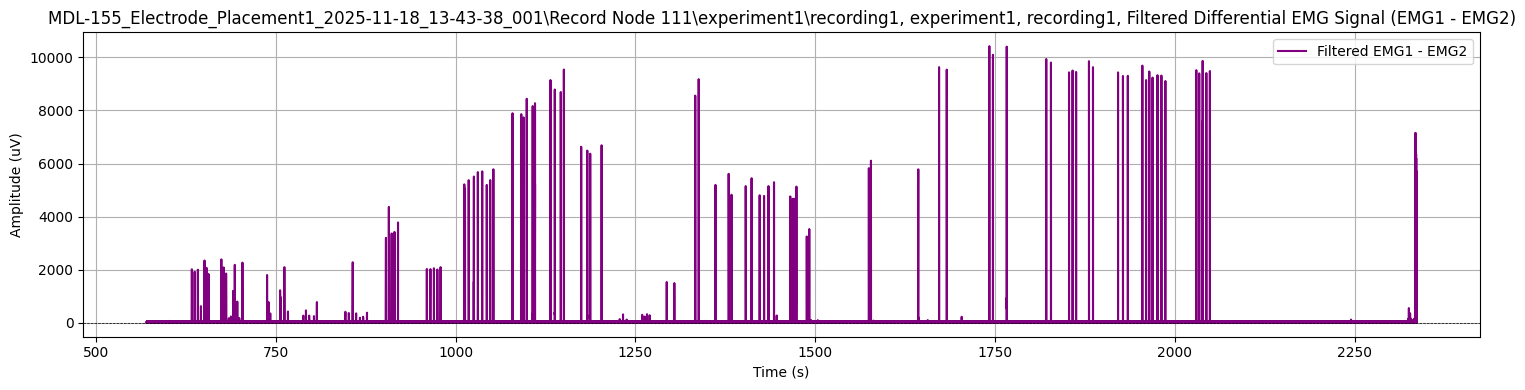

In [28]:

# Phase 1: EMG processing and full-trace plotting (using helpers.process_emg_signal)

try:
    timestamps
    data
except NameError:
    print("No recording data loaded. Please open a recording first.")
else:
    sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)
    differential_filt, differential_emg = process_emg_signal(data, record_node_name, sample_rate)

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps, differential_emg, label="Filtered EMG1 - EMG2", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (uV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [29]:
# Phase 1: Segment navigation UI (view long recordings in short windows)
segment_duration = 10  # seconds
try:
    total_time = timestamps[-1] - timestamps[0]
    num_segments = int(np.ceil(total_time / segment_duration))
    current_segment = 0

    from ipywidgets import Button, VBox
    output_segment = Output()

    def plot_segment(segment_idx):
        start_time = timestamps[0] + segment_idx * segment_duration
        end_time = min(start_time + segment_duration, timestamps[-1])
        mask = (timestamps >= start_time) & (timestamps < end_time)
        plt.figure(figsize=(15, 4))
        plt.plot(timestamps[mask] - start_time, differential_emg[mask], label="Filtered EMG", color='purple')
        # show blanking regions if available
        try:
            if 'blank_mask' in globals():
                # overlay shaded regions where blank_mask is False
                blank_mask_seg = ~blank_mask[mask]
                if blank_mask_seg.any():
                    # find contiguous runs and shade
                    idxs = np.where(mask)[0]
                    runs = []
                    run_start = None
                    for local_i, global_idx in enumerate(idxs):
                        if blank_mask_seg[local_i] and run_start is None:
                            run_start = timestamps[global_idx] - start_time
                        if (not blank_mask_seg[local_i] or local_i == len(idxs)-1) and run_start is not None:
                            run_end = timestamps[global_idx] - start_time
                            runs.append((run_start, run_end))
                            run_start = None
                    for s,e in runs:
                        plt.axvspan(s, e, color='red', alpha=0.25)
        except Exception:
            pass

        plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
        # compute and show blank fraction in this segment if available
        seg_blank_frac = 0.0
        if 'blank_mask' in globals():
            try:
                seg_mask = blank_mask[mask]
                seg_blank_frac = 1.0 - (np.sum(seg_mask) / float(seg_mask.size)) if seg_mask.size>0 else 0.0
            except Exception:
                seg_blank_frac = 0.0
        plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Segment {segment_idx+1}/{num_segments} | Time: {start_time:.1f}-{end_time:.1f}s | blank={seg_blank_frac:.2%}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude (μV)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def on_next(b):
        global current_segment
        if current_segment < num_segments - 1:
            current_segment += 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    def on_prev(b):
        global current_segment
        if current_segment > 0:
            current_segment -= 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    next_button = Button(description="Next")
    prev_button = Button(description="Previous")
    next_button.on_click(on_next)
    prev_button.on_click(on_prev)

    # Initial plot
    with output_segment:
        plot_segment(current_segment)

    display(VBox([prev_button, next_button, output_segment]))

except Exception as e:
    print("Could not set up segment navigation:", e)


In [30]:

# Phase 1: Load MessageCenter events using helpers
try:
    message_entries = load_message_center_events(
        directory_str, record_node_name, experiment_name, recording_name)
    for t, txt in message_entries[:20]:
        print(f"[Time: {t:.6f} s] Message: {txt}")
except Exception as e:
    print("MessageCenter load error:", e)
    message_entries = []

Loaded 154 MessageCenter entries from MDL-155_Electrode_Placement1_2025-11-18_13-43-38_001\Record Node 111\experiment1\recording1\events\MessageCenter
[Time: 604.189800 s] Message: Recording 1: Electrode Configuration 1
[Time: 629.543000 s] Message: Starting at 0.70 mA
[Time: 633.099200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 636.961400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 641.473800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 645.756600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 650.727800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 653.557600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 656.234400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 667.859200 s] Message: Starting at 0.80 mA
[Time: 674.130600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 677.304600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 680.746000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 684.570000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 687.438000 s] Message: RHDCONTROL TRIGGER 1 50

# Phase 2 — Blanking, Binning and Trial Sweep

This phase implements the robust sample-based "blanking" (throw-out) around event markers and provides the trial sweep / binning pipeline for offline processing. Key design points:

- Convert trigger times to sample indices to create a binary `blank_mask` (True=valid sample, False=blanked).
- Use configurable blank window (default: 10 ms pre, 50 ms post) converted to samples via the recording's sample rate.
- Implement `compute_bin_means` and `grand_mean_from_bins` that respect the blank mask and require a `min_valid_fraction` per bin.
- Implement a `sweep_trials` function that walks through the recording, picks randomized trial durations within [TRIAL_INIT_MIN_MS, TRIAL_INIT_MAX_MS] (rounded to `BIN_DURATION_MS` multiples), and saves trials that pass the mean-amplitude acceptance criteria.

All functions are vectorized where practical and are documented in-line. The results will be saved into a `trials` list with metadata for later inspection or export.

Found 125 trigger messages
Blank mask: 125 events -> 37625 samples blanked (0.0043 fraction)
Sweep complete. Collected 720 accepted trials.
Trial 0: start=0 end=13250 dur_ms=2650 grand_mean=11.01
Trial 1: start=13250 end=25250 dur_ms=2400 grand_mean=11.11
Trial 2: start=25250 end=38250 dur_ms=2600 grand_mean=11.12


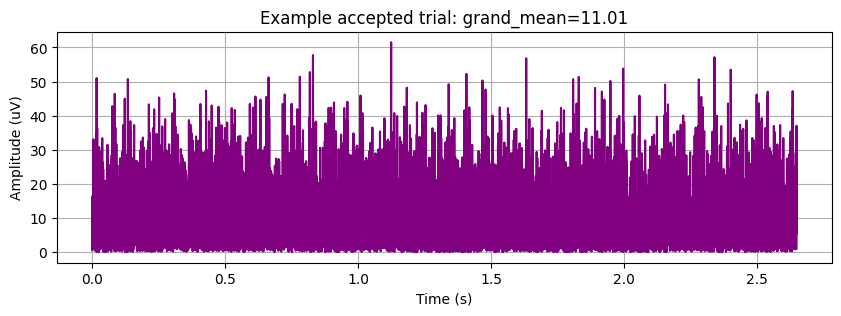

In [31]:
# Phase 2: Blanking, binning, and trial sweep
# Functions compute_bin_means, grand_mean_from_bins, round_to_nearest_multiple,
# sweep_trials are all imported from helpers.py.

# Parameters (ms)
blank_pre_ms = 10
blank_post_ms = 50
min_valid_fraction = 0.7

# Parse triggers and build blank mask using helpers
try:
    trigger_times = parse_trigger_times(message_entries)
except Exception as e:
    print("No message_entries available or parsing error:", e)
    trigger_times = []

sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)

try:
    blank_mask = build_blank_mask(timestamps, trigger_times, sample_rate,
                                  blank_pre_ms, blank_post_ms)
    globals()['blank_mask'] = blank_mask
except Exception as e:
    print("Could not create blank mask:", e)

# Run trial sweep
try:
    trials = sweep_trials(differential_emg, timestamps, blank_mask, sample_rate,
                          min_uv=TRIAL_INIT_MIN_UV, max_uv=TRIAL_INIT_MAX_UV,
                          min_valid_fraction=min_valid_fraction)
    print(f"Sweep complete. Collected {len(trials)} accepted trials.")
    for k, t in enumerate(trials[:3]):
        print(f"Trial {k}: start={t['start_sample']} end={t['end_sample']} "
              f"dur_ms={t['dur_ms']} grand_mean={t['grand_mean']:.2f}")

    # Plot example accepted trial
    if len(trials) > 0:
        t0 = trials[0]
        s, e = t0['start_sample'], t0['end_sample']
        plt.figure(figsize=(10, 3))
        plt.plot(timestamps[s:e] - timestamps[s], differential_emg[s:e], color='purple')
        blank_local = ~blank_mask[s:e]
        if blank_local.any():
            idxs = np.where(blank_local)[0]
            runs, run_start, prev_idx = [], None, None
            for pos in idxs:
                if run_start is None:
                    run_start = timestamps[s + pos] - timestamps[s]
                    prev_idx = pos
                elif pos != prev_idx + 1:
                    runs.append((run_start, timestamps[s + prev_idx] - timestamps[s]))
                    run_start = timestamps[s + pos] - timestamps[s]
                    prev_idx = pos
                else:
                    prev_idx = pos
            if run_start is not None:
                runs.append((run_start, timestamps[s + prev_idx] - timestamps[s]))
            for rs, re_ in runs:
                plt.axvspan(rs, re_, color='red', alpha=0.25)
        plt.title(f"Example accepted trial: grand_mean={t0['grand_mean']:.2f}")
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude (uV)')
        plt.grid(True)
        plt.show()

except Exception as e:
    print("Trial sweep example skipped (missing data):", e)

## Phase 2b — MH-style histogram: trial grand-means + cleaned-sample histogram 📊

This cell computes a histogram that matches the style used by `MhRecruitmentCurveStage`:

- **Primary histogram (left):** assembled *trial grand-means* (one value per accepted trial). Bins use a **1% step-size** across the primary min→max range (i.e., ~100 bins). Heights are raw **counts** (not density), and the plot includes vertical initiation-threshold lines.
- **Secondary histogram (right):** cleaned *sample-level* amplitudes (blanked samples removed) for diagnostic purposes.

Features:
- Dynamic titles/labels showing recording name, number of trials/samples, and fraction blanked. ✅
- Optional `yscale` (linear or log), and options to save PNG/JSON of histogram data.
- Exposes computed stats and arrays to the notebook namespace for downstream use (see `hist_out`, `hist_primary_stats`, etc.).

Run the histogram cell after Phase 2 to visualize the assembled binned-signal distribution and confirm initiation thresholds visually.

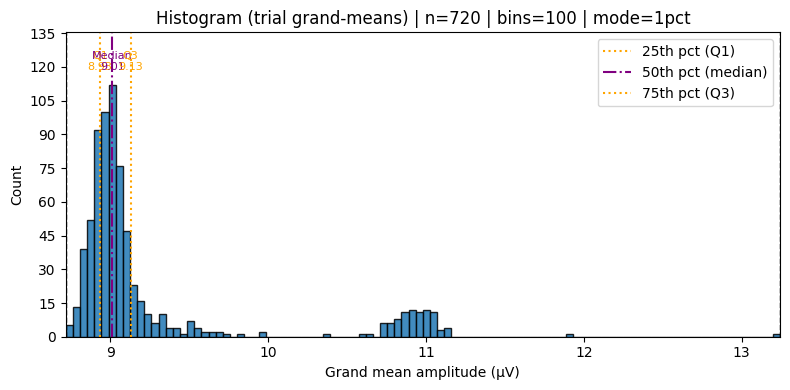

Histogram summary: n=720, min=8.716, Q1=8.933, median=9.011, Q3=9.127, max=13.243, step1%=0.057, mode=1pct


In [32]:
# Phase 2b: Histogram of trial grand-means (single panel)
import math

def compute_mh_style_histogram_and_stats(yscale='linear', save_png=False, save_json=False, num_bins=None, binning='1pct'):
    """Build an MH-style histogram of trial grand-means (single panel only).

    Returns: dict with keys: fig, ax, primary_stats, hist_vals, hist_edges, save_paths, binning
    """

    from matplotlib.ticker import MaxNLocator

    # Gather trial grand-means
    grand_means = np.array([])
    if 'trials' in globals() and len(trials) > 0:
        try:
            grand_means = np.array([float(t['grand_mean']) for t in trials])
            grand_means = grand_means[~np.isnan(grand_means)]
        except Exception:
            grand_means = np.array([])

    if grand_means.size == 0:
        print('No trial grand-means available; run sweep_trials() first.')
        fig, ax = plt.subplots(1,1,figsize=(7,4))
        ax.text(0.5,0.5,'No trial grand-means available', ha='center')
        plt.tight_layout()
        plt.show()
        primary_stats = {'n': 0}
        return {'fig': fig, 'ax': ax, 'primary_stats': primary_stats, 'hist_vals': np.array([]), 'hist_edges': np.array([]), 'save_paths': {}}

    # Compute primary stats
    mn = float(np.min(grand_means)); mx = float(np.max(grand_means)); n = int(grand_means.size)
    mean = float(np.mean(grand_means)); std_dev = float(np.std(grand_means, ddof=0))
    q25, q50, q75 = np.percentile(grand_means, [25,50,75])
    q1 = float(np.quantile(grand_means, 0.01)) if n>1 else mn
    step_one_percent = float(q1 - mn)
    if step_one_percent <= 0:
        step_one_percent = (mx - mn) / 100.0 if (mx - mn) > 0 else max(0.1, abs(mx)*0.01 if mx!=0 else 0.1)

    primary_stats = {'n': n, 'min': mn, 'max': mx, 'mean': mean, 'std_dev': std_dev, 'q25': q25, 'q50': q50, 'q75': q75, 'step_size_one_percent': step_one_percent}

    # Build histogram bins
    if binning == '1pct':
        step = step_one_percent
        edges = np.arange(mn - 0.5*step, mx + 1.5*step, step)
        if edges.size < 2:
            edges = np.linspace(mn - 0.5, mx + 0.5, 11)
        hist_vals, hist_edges = np.histogram(grand_means, bins=edges)
    elif binning == 'auto':
        hist_vals, hist_edges = np.histogram(grand_means, bins='auto')
    else:
        bins = 100 if num_bins is None else int(num_bins)
        hist_vals, hist_edges = np.histogram(grand_means, bins=bins)

    # ✅ Enforce minimum bins here
    if hist_vals.size < 100:
        hist_vals, hist_edges = np.histogram(
            grand_means,
            bins=100,
            range=(mn, mx)
        )

    # Plot single panel
    fig, ax = plt.subplots(1,1, figsize=(8,4))
    centers = (hist_edges[:-1] + hist_edges[1:]) / 2.0
    widths = (hist_edges[1:] - hist_edges[:-1])
    ax.bar(centers, hist_vals, width=widths, align='center', color='C0', edgecolor='k', alpha=0.85)
    ax.set_xlabel('Grand mean amplitude (μV)')
    ax.set_ylabel('Count')
    ax.set_title(f'Histogram (trial grand-means) | n={n:,} | bins={len(hist_vals)} | mode={binning}')

    
    
    ax.set_xlim(hist_edges[0], hist_edges[-1])
    #ax.set_xlim(11, 15) #Uncomment this line here to manually set bounds of histogram
    ax.axvline(mn, color='black', linestyle='--', linewidth=1.0, label='_nolegend_')
    ax.axvline(mx, color='black', linestyle='--', linewidth=1.0, label='_nolegend_')
    if 'TRIAL_INIT_MIN_UV' in globals():
        ax.axvline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', linewidth=1.5, label='_nolegend_')
        ax.axvline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', linewidth=1.5, label='_nolegend_')

    # Quartile lines and labels (Q1, median, Q3)
    try:
        ymax_est = int(max(hist_vals)) if hist_vals.size>0 else 1
        y_text = ymax_est * 1.05
        ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label='25th pct (Q1)')
        ax.axvline(q50, color='purple', linestyle='-.', linewidth=1.5, label='50th pct (median)')
        ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label='75th pct (Q3)')
        ax.text(q25, y_text, f'Q1\n{q25:.2f}', color='orange', ha='center', va='bottom', fontsize=8)
        ax.text(q50, y_text, f'Median\n{q50:.2f}', color='purple', ha='center', va='bottom', fontsize=8)
        ax.text(q75, y_text, f'Q3\n{q75:.2f}', color='orange', ha='center', va='bottom', fontsize=8)
    except Exception:
        pass

    ax.legend()

    ymax = int(max(hist_vals)) if hist_vals.size>0 else 1
    ax.set_ylim(0, ymax*1.2 + 1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if yscale in ('log','symlog'):
        ax.set_yscale(yscale)

    plt.tight_layout()
    plt.show()

    # Save if requested (primary histogram only)
    save_paths = {}
    if save_png and 'directory_str' in globals() and 'recording_name' in globals():
        try:
            png_path = os.path.join(directory_str, f"{recording_name}_grandmeans_histogram.png")
            fig.savefig(png_path, dpi=150)
            save_paths['png'] = png_path
        except Exception as e:
            print('Could not save histogram PNG:', e)
    if save_json and hist_vals.size > 0 and 'directory_str' in globals() and 'recording_name' in globals():
        try:
            json_path = os.path.join(directory_str, f"{recording_name}_grandmeans_histogram.json")
            hist_dict = {'hist_vals': hist_vals.tolist(), 'hist_edges': hist_edges.tolist(), 'primary_stats': primary_stats, 'binning': binning}
            with open(json_path, 'w') as jf:
                json.dump(hist_dict, jf, indent=2)
            save_paths['json'] = json_path
        except Exception as e:
            print('Could not save histogram JSON:', e)

    print(
    f"Histogram summary: "
    f"n={n}, "
    f"min={mn:.3f}, "
    f"Q1={q25:.3f}, "
    f"median={q50:.3f}, "
    f"Q3={q75:.3f}, "
    f"max={mx:.3f}, "
    f"step1%={step_one_percent:.3f}, "
    f"mode={binning}" 
    )


    return {'fig': fig, 'ax': ax, 'primary_stats': primary_stats, 'hist_vals': hist_vals, 'hist_edges': hist_edges, 'save_paths': save_paths, 'binning': binning}


# Run updated histogram and store outputs (primary grand-means only)
hist_out = compute_mh_style_histogram_and_stats(yscale='linear')
# Expose fields to globals for downstream usage (primary only)
globals().update({
    'hist_primary_stats': hist_out.get('primary_stats', {}),
    'hist_values': hist_out.get('hist_vals', np.array([])),
    'hist_edges': hist_out.get('hist_edges', np.array([])),
})


### Phase 3 — Peri-stimulus extraction, grouping, and M/H detection 





# Peri‑stimulus viewer (what this section does)

This section builds stimulation amplitude groups from the previously-extracted peri-stimulus windows and provides an interactive, paged viewer:

- Shows groups in **2x2 pages** with individual traces (faint) and the group average (bold), shaded stimulus duration, M/H windows, and annotated peaks.
- Double-click a subplot (if your frontend/backend supports it) to open a full-size zoomed view of that group.
- Use the **View** dropdown + button to reliably open a zoomed view if click events are not supported.
- While zoomed you can **Save PNG** for quick export, or return to the grid with **Back to grid**.

Troubleshooting & tips:
- If you get no groups, verify `MessageCenter` parsing and that `peri_stim_segments` was populated by the detection cell.
- Some Jupyter frontends do not support Matplotlib click events in inline mode — use the dropdown+View button in that case.
- If saving fails, check that `directory_str` and `recording_name` are available (they're set when you open a recording).


In [33]:
# Phase 3: Peri-stimulus viewer (2x2 paged, zoomable, saveable)

from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label


# ==== Peri-Stimulus Analysis with Shaded Stimulus Duration ====
pre_event_time = 5   # ms before calculated stim start
post_event_time = 20 # ms after calculated stim start
stim_threshold = 0.01 # ADC1 threshold to detect pulse (adjust if needed)
offstim_threshold = .41


m_wave_start, m_wave_end = 1.5, 4
h_wave_start, h_wave_end = 4.5, 10



peri_stim_segments = []
peri_stim_segments_adc1 = []
segment_stim_end_times = []
segment_stim_start_times = []

# ==== Sync Setup ====

differential_emg = differential_filt


# ==== Load ADC1 (for stim detection) ====
adc1 = np.abs(data[:, 4])  # adjust if your ADC1 channel index differs

# ==== Sync Events ====
events = recording.events
sync_events = events[(events.line == 1) & (events.processor_id == 100) &
                        (events.stream_name == 'Rhythm Data') & (events.state == 1)]
sync_timestamps = sync_events['timestamp'].to_numpy()


print(recording)

for stamp in sync_timestamps:
        # First, find approximate sample index around the sync pulse
        #idx_start = np.searchsorted(timestamps, stamp)
        #idx_end   = np.searchsorted(timestamps, stamp + 0.010)
        #idx_center = (idx_start + idx_end)/2

        idx_search_start = np.searchsorted(timestamps, stamp - 0.00003)  # 10 ms before sync
        idx_search_end   = np.searchsorted(timestamps, stamp + 0.010)  # 10 ms after sync

        if idx_search_start < 0 or idx_search_end > len(timestamps):
            continue

        adc1_segment_for_detection = adc1[idx_search_start:idx_search_end]
        time_segment_for_detection = timestamps[idx_search_start:idx_search_end]

        # Detect true stim start: first crossing above threshold in that window
        above_idxs = np.where(adc1_segment_for_detection > stim_threshold)[0]
        
        if len(above_idxs) == 0:
            continue
        stim_start_idx = idx_search_start + above_idxs[0]
        stim_start_time = timestamps[stim_start_idx]

        # Now define peri-stimulus window around this stim_start_time
        idx_pre  = int(stim_start_idx - (pre_event_time / 1000) * sample_rate)
        idx_post = int(stim_start_idx + (post_event_time / 1000) * sample_rate)

        if idx_pre < 0 or idx_post > len(timestamps):
            continue

        # Extract windows
        time_window = timestamps[idx_pre:idx_post]
        time_zeroed = time_window - stim_start_time  # in seconds

        emg_window  = differential_emg[idx_pre:idx_post]
        adc1_window = adc1[idx_pre:idx_post]

        # Detect stim end: first time after stim_start where ADC1 falls back below threshold
        post_onset_mask = (time_zeroed >= 0)
        adc1_post_onset = adc1_window[post_onset_mask]
        time_post_onset = time_zeroed[post_onset_mask]

        below_idxs = np.where(adc1_post_onset < offstim_threshold)[0]
        if len(below_idxs) > 0:
            stim_end_time = time_post_onset[below_idxs[0]] * 1000  # convert to ms
        else:
            stim_end_time = post_event_time

        # Save for grouping
        peri_stim_segments.append((time_zeroed * 1000, emg_window, stim_end_time))
        peri_stim_segments_adc1.append(adc1_window)
        segment_stim_start_times.append(stim_start_time)
        segment_stim_end_times.append(stim_end_time)

#print(time_window)
#print(idx_search_start)
#print(idx_search_end)
#print(peri_stim_segments_adc1)
#print(peri_stim_segments)
print(stim_end_time)


# ==== Dynamically determine stimulation groups based on event messages ====

# First, extract only trigger messages and stim setting messages
trigger_pattern = re.compile(r"RHDCONTROL TRIGGER")
stim_pattern = re.compile(r"starting(?: at)? (\d+\.?\d*)\s*mA", re.IGNORECASE)

stim_groups = []
current_group = []
current_amp = None
trigger_times = []

for t, msg in message_entries:
    if stim_pattern.search(msg):
        # Save the previous group if any
        if current_amp is not None and current_group:
            stim_groups.append((current_amp, current_group))
        # Start new group
        current_amp = float(stim_pattern.search(msg).group(1))
        current_group = []
    elif trigger_pattern.search(msg):
        if current_amp is not None:
            current_group.append(t)

# Don't forget to save the last group
if current_amp is not None and current_group:
    stim_groups.append((current_amp, current_group))


# ==== Match trigger times to peri_stim_segments ====
# Create dictionary to associate each stim amplitude to its segments
stim_intensities = []
m_wave_peaks = []
h_wave_peaks = []




# Build consolidated groups list (amp + traces + averages)
groups_list = []
for stim_amp, trigger_times_group in stim_groups:
    group_data = []
    group_adc1 = []
    for trig_time in trigger_times_group:
        if len(segment_stim_start_times) == 0:
            continue
        idx_match = np.argmin(np.abs(np.array(segment_stim_start_times) - trig_time))
        if abs(segment_stim_start_times[idx_match] - trig_time) < 0.1:
            group_data.append(peri_stim_segments[idx_match])
            group_adc1.append(peri_stim_segments_adc1[idx_match])
    if not group_data:
        continue
    time_ms_matrix = np.stack([gd[0] for gd in group_data])
    emg_matrix     = np.stack([gd[1] for gd in group_data])
    avg_time_ms = time_ms_matrix[0]
    avg_emg = np.mean(emg_matrix, axis=0)
    avg_adc1 = np.mean(group_adc1, axis=0) if len(group_adc1)>0 else None
    avg_end_ms = np.mean([gd[2] for gd in group_data])
    stim_intensities.append(stim_amp)
    traces = [gd[1] for gd in group_data]
    groups_list.append({'amp': stim_amp,
                        'time_ms': avg_time_ms,
                        'avg_emg': avg_emg,
                        'traces': traces,
                        'avg_adc1': avg_adc1,
                        'avg_end_ms': avg_end_ms})
    m_wave_mask = (avg_time_ms >= m_wave_start) & (avg_time_ms <= m_wave_end)
    m_wave_time_window = avg_time_ms[m_wave_mask]
    m_wave_emg_window = avg_emg[m_wave_mask]
    m_wave_peak_idx = np.argmax(m_wave_emg_window)
    m_wave_peak_time = m_wave_time_window[m_wave_peak_idx]
    m_wave_peak_amp = m_wave_emg_window[m_wave_peak_idx]
    m_wave_peaks.append(m_wave_peak_amp)

    h_wave_mask = (avg_time_ms >= h_wave_start) & (avg_time_ms <= h_wave_end)
    h_wave_time_window = avg_time_ms[h_wave_mask]
    h_wave_emg_window = avg_emg[h_wave_mask]
    h_wave_peak_idx = np.argmax(h_wave_emg_window)
    h_wave_peak_time = h_wave_time_window[h_wave_peak_idx]
    h_wave_peak_amp = h_wave_emg_window[h_wave_peak_idx]
    h_wave_peaks.append(h_wave_peak_amp)

if len(groups_list) == 0:
    print('No valid stimulation groups found to display. Check that peri-stimulus extraction (Phase 3 earlier cells) populated `peri_stim_segments` and that `MessageCenter` groups were found.')
else:
    # Pagination setup
    n_per_page = 4
    pages = [groups_list[i:i+n_per_page] for i in range(0, len(groups_list), n_per_page)]
    current_page = {'idx': 0}

    print(f'Prepared {len(groups_list)} stimulation groups across {len(pages)} pages. Use the controls to page through groups.')

    out = Output()

    # Dropdown used to select which subplot on the current page to zoom
    amp_dropdown = Dropdown(options=[], description='View:')
    zoom_button = Button(description='View', button_style='info')

    # Keep track of active mpl connection so we can disconnect when re-rendering
    active_conn = {'cid': None, 'canvas': None}

    def show_zoom(group):
        # Display a full-size single-plot view for the selected group
        with out:
            out.clear_output(wait=True)
            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(1, 1, figsize=(8, 5))
            t = group['time_ms']
            for tr in group['traces']:
                ax.plot(t, tr, color='red', alpha=0.4)
            ax.plot(t, group['avg_emg'], color='black', linewidth=2, label='Average')
            ax.axvspan(0, group['avg_end_ms'], color='red', alpha=0.25)
            ax.axvspan(m_wave_start, m_wave_end, color='blue', alpha=0.2)
            ax.axvspan(h_wave_start, h_wave_end, color='green', alpha=0.2)
            # peaks
            m_mask = (t >= m_wave_start) & (t <= m_wave_end)
            if np.any(m_mask):
                m_win = group['avg_emg'][m_mask]
                m_twin = t[m_mask]
                if m_win.size>0:
                    m_idx = np.argmax(m_win)
                    m_time = m_twin[m_idx]
                    m_amp  = m_win[m_idx]
                    ax.axvline(m_time, color='blue', linestyle=':', linewidth=1.5)
                    ax.text(m_time, m_amp + 0.05*np.max(group['avg_emg']), f'{m_amp:.1f} μV', color='blue', ha='center', fontsize=9)
            h_mask = (t >= h_wave_start) & (t <= h_wave_end)
            if np.any(h_mask):
                h_win = group['avg_emg'][h_mask]
                h_twin = t[h_mask]
                if h_win.size>0:
                    h_idx = np.argmax(h_win)
                    h_time = h_twin[h_idx]
                    h_amp  = h_win[h_idx]
                    ax.axvline(h_time, color='green', linestyle=':', linewidth=1.5)
                    ax.text(h_time, h_amp + 0.05*np.max(group['avg_emg']), f'{h_amp:.1f} μV', color='green', ha='center', fontsize=9)

            ax.set_title(f"Stim Amp: {group['amp']:.2f} mA | n={len(group['traces'])}")
            ax.set_xlabel('Time (ms)')
            ax.set_ylabel('Amplitude (μV)')
            ax.xaxis.set_major_locator(MultipleLocator(1))     # major ticks every 2 ms
            ax.xaxis.set_minor_locator(MultipleLocator(0.5))   # minor ticks every 0.5 ms
            ax.grid(True, which='both', alpha=0.3)

            plt.tight_layout()
            plt.show()

            # Back and Save controls
            back_button = Button(description='Back to grid', button_style='info')
            save_button = Button(description='Save PNG', button_style='success')

            def on_back(b):
                plot_page(current_page['idx'])
            back_button.on_click(on_back)

            def on_save(b):
                try:
                    save_dir = globals().get('directory_str', os.getcwd())
                    fname = f"{globals().get('recording_name','recording')}_zoom_{group['amp']:.2f}mA.png"
                    fullp = os.path.join(save_dir, fname)
                    fig.savefig(fullp, dpi=150)
                    print(f"Saved zoom PNG to: {fullp}")
                except Exception as e:
                    print('Could not save PNG:', e)

            save_button.on_click(on_save)
            display(HBox([back_button, save_button]))

    def plot_page(page_idx):
        # Disconnect previous mpl connection if any
        try:
            if active_conn['cid'] is not None and active_conn['canvas'] is not None:
                try:
                    active_conn['canvas'].mpl_disconnect(active_conn['cid'])
                except Exception:
                    pass
                active_conn['cid'] = None
                active_conn['canvas'] = None
        except Exception:
            pass

        with out:
            out.clear_output(wait=True)
            page = pages[page_idx]
            n = len(page)
            import matplotlib.pyplot as plt
            fig, axs = plt.subplots(2, 2, figsize=(12, 8))
            axs = axs.flatten()

            # Populate amp dropdown for this page
            amp_dropdown.options = [(f"{g['amp']:.2f} mA", idx) for idx, g in enumerate(page)]
            if amp_dropdown.options:
                amp_dropdown.value = 0

            for j in range(4):
                ax = axs[j]
                if j < n:
                    g = page[j]
                    t = g['time_ms']
                    # individual traces
                    for tr in g['traces']:
                        ax.plot(t, tr, color='red', alpha=0.4)
                    # average
                    ax.plot(t, g['avg_emg'], color='black', linewidth=2, label='Average')
                    # shade stimulus region
                    stim_end = g['avg_end_ms']
                    ax.axvspan(0, stim_end, color='red', alpha=0.25)
                    # M/H windows
                    ax.axvspan(m_wave_start, m_wave_end, color='blue', alpha=0.2)
                    ax.axvspan(h_wave_start, h_wave_end, color='green', alpha=0.2)
                    # find and plot peaks (if valid)
                    m_mask = (t >= m_wave_start) & (t <= m_wave_end)
                    if np.any(m_mask):
                        m_win = g['avg_emg'][m_mask]
                        m_twin = t[m_mask]
                        if m_win.size>0:
                            m_idx = np.argmax(m_win)
                            m_time = m_twin[m_idx]
                            m_amp  = m_win[m_idx]
                            ax.axvline(m_time, color='blue', linestyle=':', linewidth=1.5)
                            ax.text(m_time, m_amp + 0.05*np.max(g['avg_emg']), f'{m_amp:.1f} μV', color='blue', ha='center', fontsize=8)
                    h_mask = (t >= h_wave_start) & (t <= h_wave_end)
                    if np.any(h_mask):
                        h_win = g['avg_emg'][h_mask]
                        h_twin = t[h_mask]
                        if h_win.size>0:
                            h_idx = np.argmax(h_win)
                            h_time = h_twin[h_idx]
                            h_amp  = h_win[h_idx]
                            ax.axvline(h_time, color='green', linestyle=':', linewidth=1.5)
                            ax.text(h_time, h_amp + 0.05*np.max(g['avg_emg']), f'{h_amp:.1f} μV', color='green', ha='center', fontsize=8)

                    ax.set_title(f"Stim Amp:{g['amp']:.2f} mA | n={len(g['traces'])}")
                    ax.set_xlabel('Time (ms)')
                    ax.set_ylabel('Amplitude (μV)')
                    ax.xaxis.set_major_locator(MultipleLocator(1))     # major ticks every 2 ms
                    ax.xaxis.set_minor_locator(MultipleLocator(0.5))   # minor ticks every 0.5 ms
                    ax.grid(True, which='both', alpha=0.3)
                    ax.grid(True)
                    try:
                        ax.set_xlim(left=np.min(t), right=np.max(t))
                    except Exception:
                        pass
                else:
                    ax.axis('off')

            plt.tight_layout()
            plt.show()

            # Try to attach click/double-click handler (some backends may not support it)
            try:
                def on_mpl_click(event):
                    # Only respond if click is inside an axis shown
                    if event.inaxes is None:
                        return
                    # find which subplot was clicked
                    for k, ax in enumerate(axs):
                        if event.inaxes == ax:
                            # double click zooms (may not be available in some frontends)
                            if getattr(event, 'dblclick', False):
                                show_zoom(page[k])
                            else:
                                # single click selects the subplot in dropdown for manual zoom
                                amp_dropdown.value = k
                            break
                cid = fig.canvas.mpl_connect('button_press_event', on_mpl_click)
                active_conn['cid'] = cid
                active_conn['canvas'] = fig.canvas
            except Exception:
                # interactive clicks may not be available; user can use the dropdown+Zoom button
                print('Click-to-zoom not available in this backend. Use the "View" button or dropdown to select a subplot.')

    def on_next(b):
        if current_page['idx'] < len(pages) - 1:
            current_page['idx'] += 1
            plot_page(current_page['idx'])

    def on_prev(b):
        if current_page['idx'] > 0:
            current_page['idx'] -= 1
            plot_page(current_page['idx'])

    def on_dropdown_change(change):
        # Respond to page dropdown changes (value -> new page index)
        if 'new' in change:
            current_page['idx'] = change['new']
            plot_page(current_page['idx'])

    def on_zoom_click(b):
        # Zoom the selected item in the current page
        sel = amp_dropdown.value
        try:
            sel_idx = int(sel)
            page = pages[current_page['idx']]
            if 0 <= sel_idx < len(page):
                show_zoom(page[sel_idx])
        except Exception:
            print('Could not zoom selected group. Check dropdown selection.')

    next_button = Button(description='Next', button_style='primary')
    prev_button = Button(description='Previous')
    page_dropdown = Dropdown(options=[(f'Page {i+1}', i) for i in range(len(pages))], description='Page:')

    next_button.on_click(on_next)
    prev_button.on_click(on_prev)
    page_dropdown.observe(on_dropdown_change)
    zoom_button.on_click(on_zoom_click)

    controls = HBox([prev_button, next_button, page_dropdown, Label(' '), amp_dropdown, zoom_button])

    # Initial render
    display(VBox([controls, out]))
    plot_page(0)

Open Ephys GUI Recording
ID: 0x2774ca937d0
Format: Binary
Directory: MDL-155_Electrode_Placement1_2025-11-18_13-43-38_001\Record Node 111\experiment1\recording1
Experiment Index: 0
Recording Index: 0
0.3999999998995918
Prepared 24 stimulation groups across 6 pages. Use the controls to page through groups.


## Phase 4 — Recruitment normalization and saving results

In this phase we normalize the M-wave amplitudes to M_max and compute the current corresponding to 50% M_max (interpolation). We also annotate H_max and the corresponding current. Results (trials and amplitude summaries) can be exported for downstream analysis.

In [34]:
# Phase 4: Normalize recruitment curves and save results
from scipy.interpolate import interp1d
import json

if 'amp_results' not in globals() or len(amp_results)==0:
    print("No amplitude results available to normalize.")
else:
    amps_sorted = sorted(amp_results.keys())
    m_means = np.array([amp_results[a]['m_amp'] for a in amps_sorted])
    h_means = np.array([amp_results[a]['h_amp'] for a in amps_sorted])
    # Use absolute values
    m_means_abs = np.abs(m_means)
    h_means_abs = np.abs(h_means)

    M_max = np.max(m_means_abs)
    if M_max == 0:
        print("M_max is zero; cannot normalize.")
    else:
        m_norm = (m_means_abs / M_max) * 100.0
        h_norm = (h_means_abs / M_max) * 100.0

        # Interpolate to find current at 50% Mmax
        try:
            interp_func = interp1d(m_norm, amps_sorted, kind='linear', bounds_error=False, fill_value='extrapolate')
            current_at_50 = float(interp_func(50.0))
        except Exception:
            current_at_50 = np.nan

        H_max = np.nanmax(h_norm)
        idx_Hmax = int(np.nanargmax(h_norm)) if not np.all(np.isnan(h_norm)) else None
        current_at_Hmax_norm = (amps_sorted[idx_Hmax] / current_at_50) if (idx_Hmax is not None and not np.isnan(current_at_50) and current_at_50 != 0) else np.nan

        # Plot normalized curves
        plt.figure(figsize=(8,4))
        plt.plot(np.array(amps_sorted)/current_at_50, m_norm, 'o-', color='blue', label='M (% Mmax)')
        plt.plot(np.array(amps_sorted)/current_at_50, h_norm, 's-', color='green', label='H (% Mmax)')
        plt.axhline(H_max, color='green', linestyle='--', label=f'H_max = {H_max:.1f}%')
        if not np.isnan(current_at_Hmax_norm):
            plt.axvline(current_at_Hmax_norm, color='gray', linestyle='--', label=f'Current at H_max = {current_at_Hmax_norm:.2f}x')
        plt.xlabel('Current (Normalized to Current at 50% Mmax)')
        plt.ylabel('% of Mmax')
        plt.title('Normalized Recruitment Curves')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Save results
        results = {
            'amps_sorted': amps_sorted,
            'm_means_abs': m_means_abs.tolist(),
            'h_means_abs': h_means_abs.tolist(),
            'm_norm': m_norm.tolist(),
            'h_norm': h_norm.tolist(),
            'M_max': float(M_max),
            'H_max': float(H_max),
            'current_at_50': float(current_at_50)
        }

#        save_path = os.path.join(DEFAULT_DATA_DIR, f"recruitment_summary_{experiment_name}_{recording_name}.json")
#        try:
#            with open(save_path, 'w') as f:
#               json.dump(results, f, indent=2)
#            print(f"Saved recruitment summary to {save_path}")
#        except Exception as e:
#            print("Could not save recruitment summary:", e)''

No amplitude results available to normalize.


C:\Users\dal866445\AppData\Local\Temp\ipykernel_14136\3080696344.py:18: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  m_sems  = np.array([stats.sem(peaks) for peaks in m_wave_data])
C:\Users\dal866445\AppData\Local\Temp\ipykernel_14136\3080696344.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  h_sems  = np.array([stats.sem(peaks) for peaks in h_wave_data])


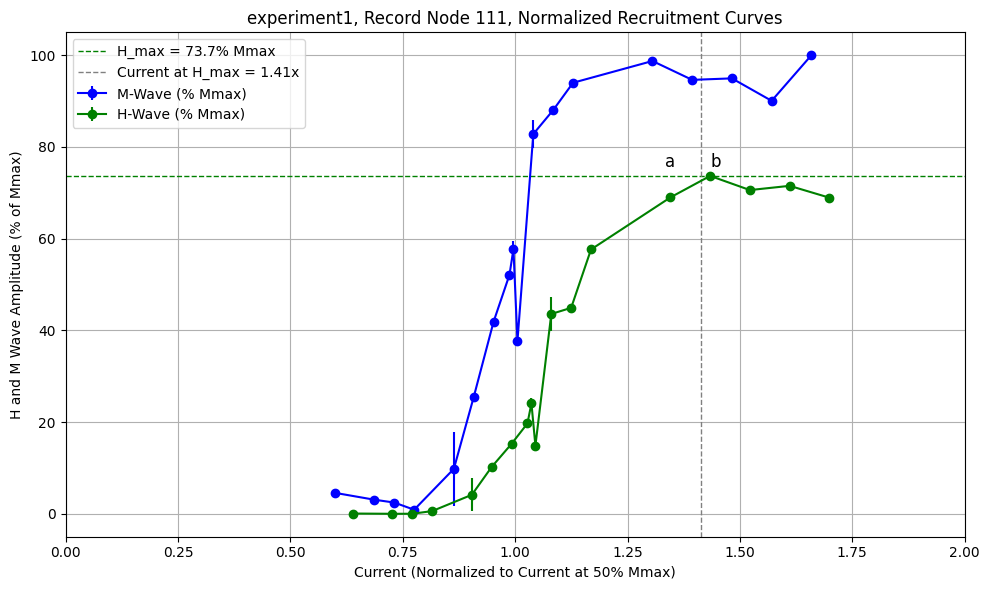

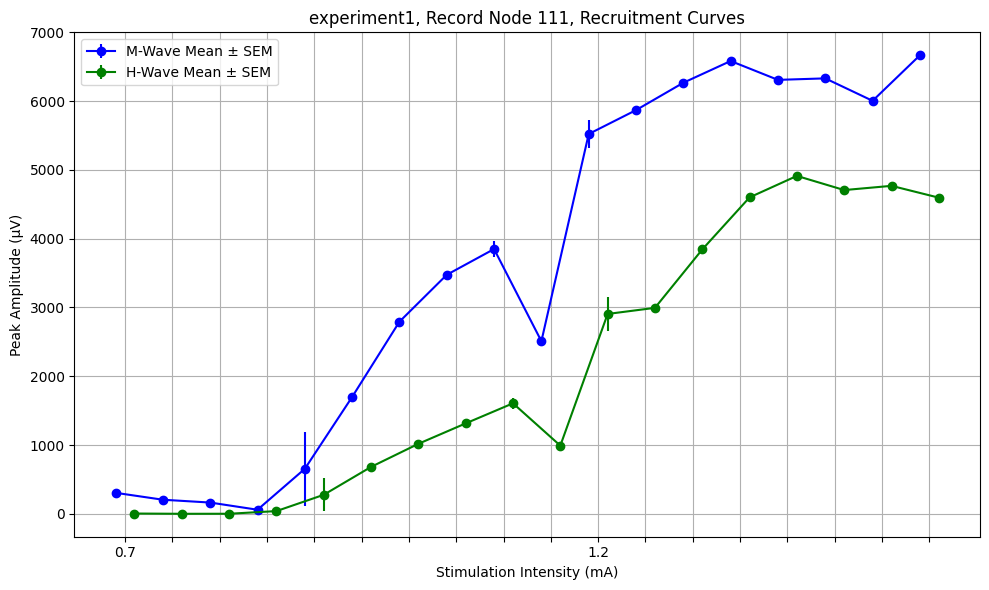

In [35]:
# ==== Group and Normalize Peak Amplitudes ====
m_wave_dict = defaultdict(list)
h_wave_dict = defaultdict(list)

# Ensure all amplitudes are absolute values
for amp, m_peak, h_peak in zip(stim_intensities, m_wave_peaks, h_wave_peaks):
    m_wave_dict[amp].append(abs(m_peak))
    h_wave_dict[amp].append(abs(h_peak))

# Sort stimulation intensities
sorted_amps = sorted(set(stim_intensities))
m_wave_data = [m_wave_dict[amp] for amp in sorted_amps]
h_wave_data = [h_wave_dict[amp] for amp in sorted_amps]

# Compute means
m_means = np.array([np.mean(peaks) for peaks in m_wave_data])
h_means = np.array([np.mean(peaks) for peaks in h_wave_data])
m_sems  = np.array([stats.sem(peaks) for peaks in m_wave_data])
h_sems  = np.array([stats.sem(peaks) for peaks in h_wave_data])

# Find M_max and normalize amplitudes
M_max = np.max(m_means)
m_means_norm = (m_means / M_max) * 100
h_means_norm = (h_means / M_max) * 100
m_sems_norm  = (m_sems  / M_max) * 100
h_sems_norm  = (h_sems  / M_max) * 100

# Interpolate M-curve to find current at 50% M_max
from scipy.interpolate import interp1d

interp_func = interp1d(m_means_norm, sorted_amps, kind='linear', bounds_error=False, fill_value='extrapolate')
try:
    current_at_50_percent = float(interp_func(50))
except:
    current_at_50_percent = sorted_amps[np.argmax(m_means_norm >= 50)]

# Normalize current axis
normalized_currents = np.array(sorted_amps) / current_at_50_percent

# Mark H_max (point "a") and Current at H_max (point "b")
H_max = np.max(h_means_norm)
idx_Hmax = np.argmax(h_means_norm)
current_at_Hmax_norm = normalized_currents[idx_Hmax]

# ==== Plot Normalized Recruitment Curves ====
fig, ax = plt.subplots(figsize=(10, 6))

# Overlay normalized mean ± SEM
ax.errorbar(normalized_currents - 0.02, m_means_norm, yerr=m_sems_norm, fmt='o-', color='blue', label='M-Wave (% Mmax)')
ax.errorbar(normalized_currents + 0.02, h_means_norm, yerr=h_sems_norm, fmt='o-', color='green', label='H-Wave (% Mmax)')

# Add point "a" (H_max) and "b" (Current at H_max)
ax.axhline(H_max, color='green', linestyle='--', linewidth=1, label=f'H_max = {H_max:.1f}% Mmax')
ax.axvline(current_at_Hmax_norm, color='gray', linestyle='--', linewidth=1, label=f'Current at H_max = {current_at_Hmax_norm:.2f}x')

# Add labels
ax.text(current_at_Hmax_norm + 0.02, H_max + 2, 'b', fontsize=12, color='black')
ax.text(normalized_currents[idx_Hmax] - 0.08, H_max + 2, 'a', fontsize=12, color='black')

# Aesthetics
#ax.set_xticks(np.round(normalized_currents, 2))
#ax.set_xticklabels([f"{x:.2f}" for x in normalized_currents])
ax.set_xlabel("Current (Normalized to Current at 50% Mmax)")
ax.set_ylabel("H and M Wave Amplitude (% of Mmax)")
ax.set_title(f"{experiment_name}, {record_node_name}, Normalized Recruitment Curves")
ax.grid(True)
ax.legend()
# Set window size here
ax.set_xlim(right=2)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()



# ==== Plot Recruitment Curves as Box-and-Whisker ====
fig, ax = plt.subplots(figsize=(10, 6))



# Boxplots
positions = np.arange(len(sorted_amps))  # for spacing

#Overlay mean ± SEM
ax.errorbar(positions - 0.2, m_means, yerr=m_sems, fmt='o-', color='blue', label='M-Wave Mean ± SEM')
ax.errorbar(positions + 0.2, h_means, yerr=h_sems, fmt='o-', color='green', label='H-Wave Mean ± SEM')

# Aesthetics
ax.set_xticks(positions)
tick_labels = []
for i, amp in enumerate(sorted_amps):
    if i % 10 == 0:  # show every 10th label
        tick_labels.append(f"{amp:.1f}")
    else:
        tick_labels.append("")  # leave blank

ax.set_xticklabels(tick_labels)

#ax.set_xticklabels([f"{amp:.1f}" for amp in sorted_amps])
ax.set_xlabel("Stimulation Intensity (mA)")
ax.set_ylabel("Peak Amplitude (μV)")
ax.set_title(f"{experiment_name}, {record_node_name}, Recruitment Curves")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

